# 本章总结（要点小结）

本章在上一章“过拟合”的基础上，介绍了最经典的正则化手段之一——**权重衰退（Weight Decay）**，即 **L2 正则化**。它通过惩罚较大的权重参数来控制模型容量，从而提高模型的泛化能力。

---

## 1. 核心数学原理

为了防止过拟合，我们有两种限制模型容量的方式：**一是减少参数量（网络结构变窄/浅）**；**二是限制参数的取值范围**。权重衰退走的是第二条道路。

### A. 从硬性限制到柔性惩罚
* **硬性限制 (Hard Constraint)**：直接将权重限定在一个半径为 $\theta$ 的超球体中：
  $$\min_{\mathbf{w}, b} L(\mathbf{w}, b) \quad \text{subject to} \quad \|\mathbf{w}\|^2 \le \theta$$
* **柔性惩罚 (Soft Constraint)**：通过拉格朗日乘子法，将约束项作为惩罚项并入损失函数中，形成无约束的目标函数：
  $$\min_{\mathbf{w}, b} L(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2$$
  其中，超参数 $\lambda > 0$（在PyTorch中称为 `weight_decay`）控制正则化的强度。$\lambda$ 越大，模型越偏向于简单的权重（偏向原点），模型容量越小。

### B. 为什么叫“权重衰退”？（更新公式推导）
使用随机梯度下降（SGD）更新带 L2 正则化的目标函数时，权重的更新法则为：
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \frac{\partial}{\partial \mathbf{w}} \left( L(\mathbf{w}_t, b_t) + \frac{\lambda}{2} \|\mathbf{w}_t\|^2 \right) = (1 - \eta \lambda) \mathbf{w}_t - \eta \frac{\partial L(\mathbf{w}_t, b_t)}{\partial \mathbf{w}}$$
* **衰退效应**：由于学习率 $\eta > 0$ 且 $\lambda > 0$，所以乘子 $(1 - \eta \lambda) < 1$。
* **物理直觉**：在每一次迭代中，优化器会**首先将当前的权重缩小一个比例（即“衰退”）**，然后再加上常规损失函数对权重的负梯度。

---

## 2. 几何直觉：拉格朗日乘子的相切效应

若没有正则项，损失函数 $L(\mathbf{w})$ 的最优解位于其等高线的中心点 $\mathbf{w}^*$。
* 正则化惩罚项 $\frac{\lambda}{2}\|\mathbf{w}\|^2$ 以原点为圆心。
* **平衡最优解**：加入正则项后，目标函数的最优解 $\mathbf{w}_{\text{reg}}^*$ 发生在**损失函数的等高线与正则惩罚项的圆相切的地方**。
* **“两力平衡”**：此时，数据拟合的“拉力”（损失函数的梯度 $-\nabla L$）与指向原点的“回弹力”（$-\lambda \mathbf{w}$）达成平衡。

---

## 3. 权重衰退的实现细节：SGD vs AdamW

在深度学习框架中，通常有两种实现 L2 正则化的方式：
1. **显式添加 (Explicit L2)**：在原有 Loss 的基础上加上 $\frac{\lambda}{2}\|\mathbf{w}\|^2$ 之后进行反向传播。
2. **优化器隐式实现 (Decoupled Weight Decay)**：直接在优化器参数中设置 `weight_decay = lambd`。
   * **SGD 下的等价性**：在 SGD 下，这两种写法在数学和更新结果上**完全等价**。
   * **Adam 下的背离（AdamW 的诞生）**：在自适应梯度算法（如 Adam）中，因为二阶动量的分母归一化，将 L2 惩罚项放在 Loss 里会导致它的梯度被历史梯度方差除以，从而使权重衰退的强度与梯度大小反相关。这背离了权重衰退的初衷（恒定的缩小比例）。因此，**AdamW 优化器**被开发出来，它在计算完 Adam 梯度更新后，再将权重衰退直接作用在权重上，实现了二者的解耦。

---

## 4. L2 正则化 (权重衰退) vs L1 正则化

| 正则化类型 | 惩罚项式 | 梯度形式 | 对权重的影响 | 物理直觉 |
| :--- | :--- | :--- | :--- | :--- |
| **L2 正则 (Weight Decay)** | $\frac{1}{2} \|\mathbf{w}\|_2^2$ | $\lambda \mathbf{w}$ | 权重整体向原点收缩，但不会轻易收缩到绝对的 $0$。 | 倾向于让权重**小而分散**，防止少数权重值极大，鼓励多特征协同作用。 |
| **L1 正则** | $\|\mathbf{w}\|_1$ | $\lambda \text{sign}(\mathbf{w})$ | 倾向于产生稀疏的权重矩阵，使大量权重变为**精确的 0**。 | 可用于**特征选择 (Feature Selection)**，使模型更具解释性。 |

---

## 5. 本章知识脉络图

```mermaid
graph TD
    A[权重衰退/L2正则化] --> B(核心思想)
    B -->|缩小模型容量| C[限制参数取值范围]
    B -->|几何直觉| D[拉格朗日乘子/等高线相切]
    
    A --> E(数学推导)
    E -->|目标函数| F[损失 + L2惩罚项]
    E -->|更新公式| G[w 乘以缩减因子 1 - lr*decay]
    
    A --> H(框架实现)
    H -->|手动实现| I[显式将 L2 范数加到 Loss 后求导]
    H -->|简洁实现| J[优化器自带 weight_decay 参数]
    J -->|优化器差异| K[SGD中等价; Adam中不等价, 推荐使用 AdamW]
```

---

## 6. 主要收获与核心思考

1. **为什么权重衰退能减轻过拟合？它在物理上代表了什么？**
   * 从经典物理或信号处理的角度看，大权重意味着输出对输入中微小的变化极其敏感（表现出高频震荡和不稳定）。权重衰退将参数压制到较小的值，使得网络表现得平滑和稳定，只关注宏观趋势，自动过滤了训练集中的微小噪声。
2. **在 PyTorch 中使用 `weight_decay` 时，一般会将偏置 $b$ 也一起进行衰减吗？**
   * **通常不衰减偏置 $b$**。因为偏置只是控制输出的平移，而不是输入特征的敏感度。惩罚偏置对减轻过拟合几乎没有帮助，反而可能导致模型拟合能力下降。在 PyTorch 中可以通过为不同参数组设置不同的超参数来排除偏置的衰减，但即使对偏置进行了微小的衰减，通常也不会带来灾难性的后果。
3. **当权重衰退的超参数 $\lambda$ 调得过大或过小时分别会发生什么？**
   * $\lambda \to 0$：退化为无正则化的标准网络，极易发生过拟合。
   * $\lambda \to \infty$：对权重的惩罚压倒了对数据拟合的追求，权重将被强行压倒在 0 附近，导致模型无法学习任何有用信息，产生严重的欠拟合。

# 1. 权重衰退

① **权重衰退是常见的处理过拟合的一种方法**。

![image.png](attachment:image.png)

② 把模型容量控制比较小有两种方法，方法一：模型控制的比较小，使得模型中参数比较少。方法二：控制参数选择范围来控制参数容量。

③ 如下图所示，w向量中每一个元素的值都小于θ的根号。

④ **约束就是正则项。** 每个特征的权重都大会导致模型复杂，从而导致过拟合。控制权重矩阵范数可以使得减少一些特征的权重，甚至使他们权重为0，从而导致模型简单，减轻过拟合。

## 使用均方范数作为硬性限制

![image.png](attachment:image.png)

## 使用均方范数作为柔性限制

⑤ λ是一个平滑的，不像以前的硬性限制，可以通过**增加λ来减小模型复杂度**。

![image.png](attachment:image.png)

⑥ 拉格朗日乘子法原本是用于解决约束条件下的多元函数极值问题。举例，求f(x,y)的最小值，但是有约束C(x,y) = 0。乘子法给的一般思路是，构造一个新的函数g(x,y,λ) = f(x,y) +λC(x,y)，当同时满足g'x = g'y = 0时，函数取到最小值。这件结论的几何含义是，当f(x,y)与C(x,y)的等高线相切时，取到最小值。

⑦ 具体到机器学习这里，C(x,y) = w^2 -θ。所以视频中的黄色圆圈，代表不同θ下的约束条件。θ越小，则最终的parameter离原点越近。

① 绿色的线就是原始损失函数l的等高线，优化原始损失l的最优解(波浪号即最优解)在中心位置。

② 当原始损失加入二分之λ的项后，这个项是一个二次项，假如w就两个值，x1(横轴)、x2(纵轴)，那么在图上这个二次项的损失以原点为中心的等高线为橙色的图所示。所以合并后的损失为绿色的和黄色的线加一起的损失。

③ 当加上损失项后，可以知道原来最优解对应的二次项的损失特别大，因此原来的最优解不是加上二次项后的公式的最优解了。若沿着橙色的方向走，原有l损失值会大一些，但是二次项罚的损失会变小，当拉到平衡点以内时，惩罚项减少的值不足以原有l损失增大的值，这样w * 就是加惩罚项后的最优解。


④ 损失函数加上正则项成为目标函数，目标函数最优解不是损失函数最优解。正则项就是防止达到损失函数最优导致过拟合，把损失函数最优点往外拉一拉。鼓励权重分散，将所有额特征运用起来，而不是依赖其中的少数特征，并且权重分散的话它的内积就小一些。

⑤ l2正则项会对大数值的权值进行惩罚。

![image.png](attachment:image.png)

回顾平方损失：
![image-2.png](attachment:image-2.png)

① 相对原来的权重更新，再减去一个值后，使得这个权重更进一步减小，这样会导致这个权重所占的比例进一步减小。

## 参数更新法则

![image.png](attachment:image.png)

![image.png](attachment:image.png)

# 2. 权重衰退（使用自定义）

① 权重衰退是最广泛使用的正则化的技术之一。

② 像以前一样生成一些数据：$y = 0.05 + \sum_{i = 1}^d 0.01 x_i + \epsilon \text{ where }
\epsilon \sim \mathcal{N}(0, 0.01^2)$

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5 # 数据越简单，模型越复杂，越容易过拟合。num_inputs为特征维度
true_w, true_b = torch.ones((num_inputs,1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train) # 生成人工数据集
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

# 初始化模型参数
def init_params():
    w = torch.normal(0,1,size=(num_inputs,1),requires_grad=True)
    b = torch.zeros(1,requires_grad=True)
    return [w,b]

# 定义L2范数惩罚
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

# 定义训练函数
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 1000, 0.003
    animator = d2l.Animator(xlabel='epoch',ylabel='loss',yscale='log',xlim=[5,num_epochs],legend=['train','test'])                   
    for epoch in range(num_epochs):
        for X, y in train_iter:
            #with torch.enable_grad():
            l = loss(net(X),y) + lambd * l2_penalty(w) ##本节核心
            l.sum().backward()
            d2l.sgd([w,b],lr,batch_size)
        if(epoch+1) % 5 == 0:
            if(epoch+1) % 5 ==0:
                animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss), d2l.evaluate_loss(net,test_iter,loss)))
    print('w的L2范数是',torch.norm(w).item()) 

In [16]:
help(d2l.synthetic_data) # 查看函数用法

Help on function synthetic_data in module d2l.torch:

synthetic_data(w, b, num_examples)
    Generate y = Xw + b + noise.
    
    Defined in :numref:`sec_linear_scratch`



w的L2范数是 12.793307304382324


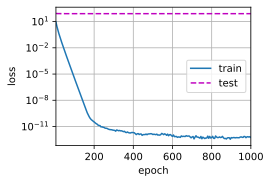

In [2]:
# 忽略正则化直接训练
train(lambd=0)  # 训练集小，过拟合，测试集损失不下降

w的L2范数是 0.013877076096832752


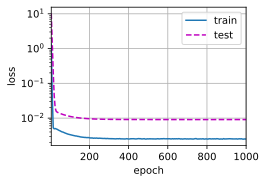

In [3]:
# 使用权重衰退
train(lambd=16)

# 3. 权重衰退（使用框架）

In [4]:
# 简洁实现：用 PyTorch 优化器的 weight_decay 做权重衰退（等价于对 w 加 L2 正则）
def train_concise(wd):
    # 单层线性模型：num_inputs 维特征 -> 1 维输出（与前面自定义实现同一设定）
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    # 权重、偏置用正态分布随机初始化（每次调用函数都会重新建模型、重新初始化）
    for param in net.parameters():
        param.data.normal_()

    loss = nn.MSELoss()          # 均方误差，只衡量预测与标签的差距，不含正则项
    num_epochs, lr = 100, 0.003  # 训练轮数、学习率（超参数，与 wd 无关）

    # 参数分组传给 SGD：
    # - net[0].weight 设置 weight_decay=wd：每步更新时额外惩罚大权值（L2 / 权重衰退）
    # - net[0].bias 不设 weight_decay：偏置通常不做 L2 正则（常见做法）
    # 等价于最小化 l(w) + (wd/2)*||w||^2（在 SGD 下与手动在损失里加 λ/2||w||^2 一致，λ 与 wd 对应）
    trainer = torch.optim.SGD(
        [{"params": net[0].weight, "weight_decay": wd},
         {"params": net[0].bias}],
        lr=lr,
    )

    # 动画：纵轴为 loss（对数刻度），每 5 个 epoch 记录一次训练集与测试集损失
    animator = d2l.Animator(
        xlabel='epoch', ylabel='loss', yscale='log',
        xlim=[5, num_epochs], legend=['train', 'test'],
    )

    for epoch in range(num_epochs):
        for X, y in train_iter:  # 按 mini-batch 遍历训练集
            with torch.enable_grad():  # 确保可以计算梯度（在部分环境下显式打开）
                trainer.zero_grad()    # 清空上一步累积的梯度
                l = loss(net(X), y)    # 前向：预测 -> 当前 batch 的 MSE（仍无正则项）

            l.backward()   # 反向传播，得到 ∂l/∂w、∂l/∂b
            trainer.step() # 参数更新：w 先按梯度下降，再按 weight_decay 收缩（见 optim.SGD 文档）

            # 每 5 轮在整集上评估平均损失，用于画 train/test 曲线（观察过拟合是否缓解）
            if (epoch + 1) % 5 == 0:
                train_l = d2l.evaluate_loss(net, train_iter, loss)
                test_l = d2l.evaluate_loss(net, test_iter, loss)
                animator.add(epoch + 1, (train_l, test_l))

    # wd 越大，||w|| 通常越小；可与 wd=0 时的范数对比
    print('w的L2范数是', net[0].weight.norm().item())

w的L2范数是 14.103032112121582


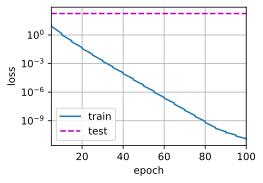

In [6]:
# 这些图看起来和我们从零开始实现权重衰减时的图相同
train_concise(0)

w的L2范数是 0.10264363884925842


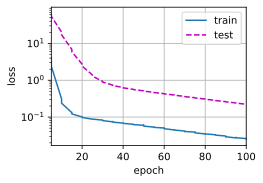

In [7]:
train_concise(10)